In [ ]:
import pandas as pd 

import numpy as np 
import matplotlib.pyplot as plt 

import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

df.head()

## Steps to EDA

1. Data Cleaning
2. Exploratory data analysis
3. Feature engineering

In [ ]:
df.shape

In [ ]:
df.info

In [ ]:
df.describe()

In [ ]:
#missing values

df.isnull().sum()

In [ ]:
# insights and observations

## the datasets has missing values

df.head(2)

# Data Cleaning

In [ ]:
# check if all the values in number

df['Reviews'].unique()

In [ ]:
df['Reviews'].str.isnumeric().sum()

In [ ]:
df[df['Reviews'].str.isnumeric()]

In [ ]:
df_copy = df.copy()

In [ ]:
df_copy = df_copy.drop(df_copy.index[10472])

df_copy[df_copy['Reviews'].str.isnumeric()]

In [ ]:
df_copy['Reviews'] = df_copy['Reviews'].astype(int)

In [ ]:
df_copy.info()

In [ ]:
df_copy['Size'] = df_copy['Size'].str.replace('M', '000')
df_copy['Size'] = df_copy['Size'].str.replace('k', '')
df_copy['Size'].unique()

In [ ]:
df_copy['Size'].isnull().sum()

In [ ]:
df_copy['Size'].unique()

In [ ]:
df_copy['Size'] = df_copy['Size'].replace('Varies with device', np.nan)
df_copy['Size'] = df_copy['Size'].astype(float)

In [ ]:
df_copy.head()

In [ ]:

df_copy['Installs'].unique()

In [ ]:
prices_to_remove = ['+', "$", ","]
installs_to_remove = ['Installs','Price']

for item in prices_to_remove:
    for cols in installs_to_remove:
        df_copy[cols] = df_copy[cols].str.replace(item, '', regex=False)


In [ ]:
df_copy['Price'].unique()

In [ ]:


df_copy['Installs'] = df_copy['Installs'].astype(int)
df_copy['Price'] = df_copy['Price'].astype(float)

In [ ]:
df_copy.head()

In [ ]:
# 1. Convert to datetime
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'], errors='coerce')

# 2. Extract separate numeric features
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year


In [ ]:
df_copy.head()

# EDA

In [ ]:
df_copy[df_copy.duplicated('App')].shape

In [ ]:
# it means dataset have duplicates records

df_copy = df_copy.drop_duplicates(subset=['App'], keep='first')
df_copy.shape


## Now lets start the EDA part (Explore data)

### Iska matlab hai Exploratory Data Analysis (EDA) ki shuruat karna.
Data cleaning ke baad, dataset ko aage analyze ya plot karne se pehle hum Explore karte hain ki hamare paas kitne columns Numerical (Numbers/Digits) hain aur kitne Categorical (Text/Categories) hain.


In [ ]:
# 1. Numerical columns (int, float)
numeric_features = df_copy.select_dtypes(include=['number']).columns.tolist()

# 2. Categorical columns (object, string, text)
categorical_features = df_copy.select_dtypes(include=['object', 'string', 'str', 'category']).columns.tolist()

# Print results
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))


In [ ]:
df_copy.dtypes

In [47]:
# proportion of count data on categorical columns

for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100 )
    print("-------------------------------")

App
ROBLOX                                               0.083018
CBS Sports App - Scores, News, Stats & Watch Live    0.073794
Duolingo: Learn Languages Free                       0.064570
Candy Crush Saga                                     0.064570
8 Ball Pool                                          0.064570
                                                       ...   
Sya9a Maroc - FR                                     0.009224
Fr. Mike Schmitz Audio Teachings                     0.009224
Parkinson Exercices FR                               0.009224
The SCP Foundation DB fr nn5n                        0.009224
iHoroscope - 2018 Daily Horoscope & Astrology        0.009224
Name: proportion, Length: 9660, dtype: float64
-------------------------------
Category
FAMILY                 18.190204
GAME                   10.552532
TOOLS                   7.776035
MEDICAL                 4.270824
BUSINESS                4.243151
PRODUCTIVITY            3.911078
PERSONALIZATION         3.61

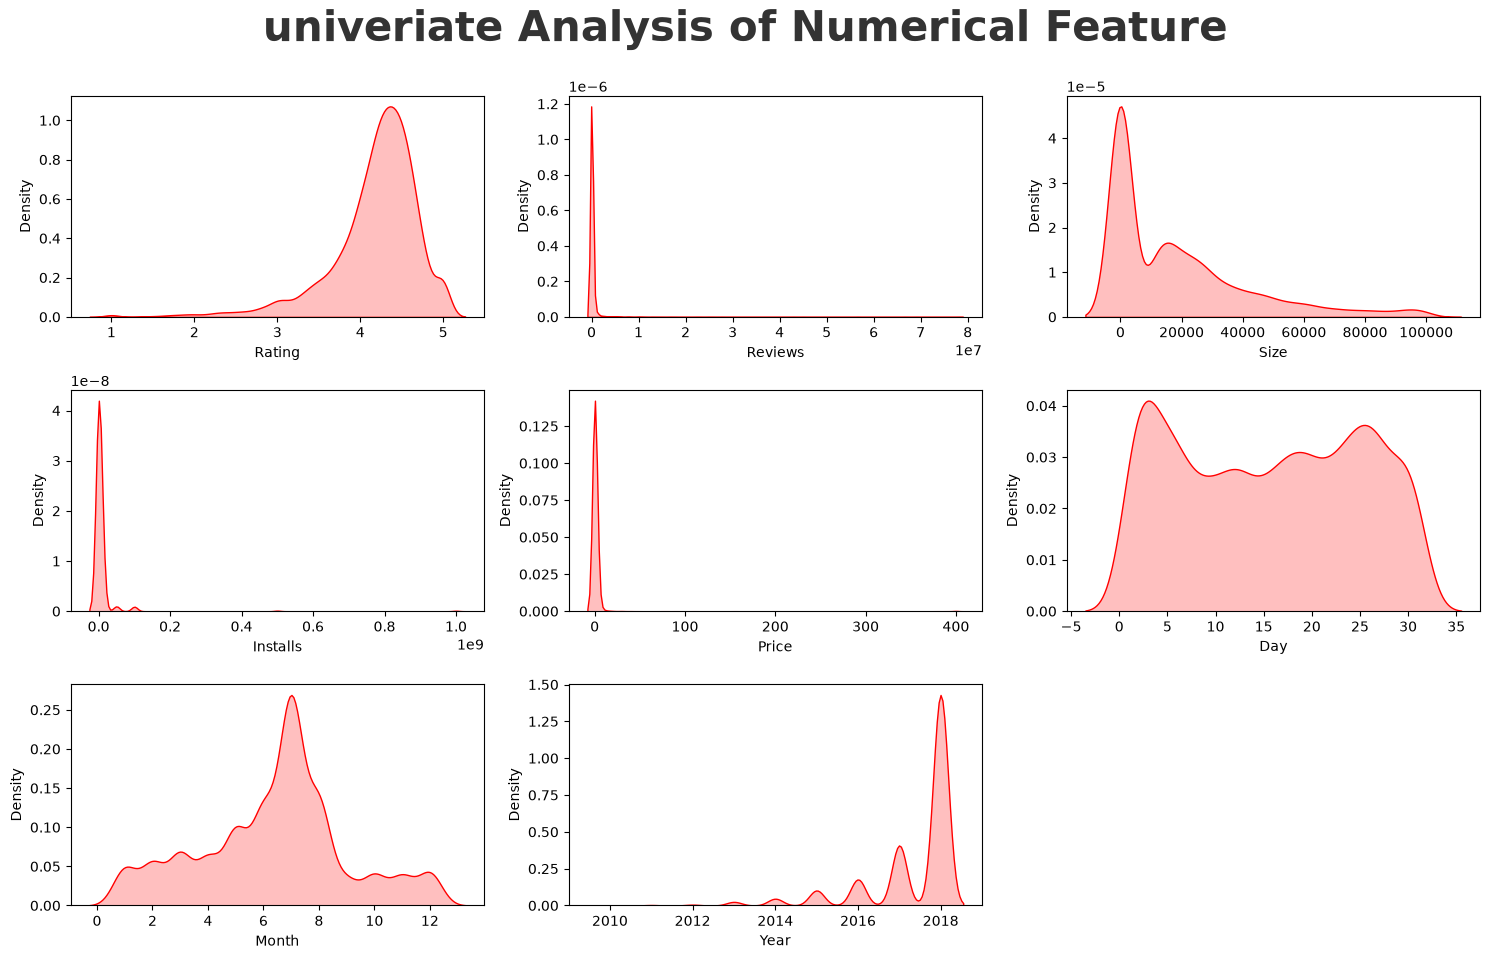

In [55]:
# proportion of count data on numerical columns
plt.figure(figsize=(15,15))
plt.suptitle("univeriate Analysis of Numerical Feature", fontsize=30, fontweight='bold', alpha=0.8, y=1)

for i in range(0, len(numeric_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]], shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

## so our observations are:
- Rating and year are left skewed and rest are right skewee

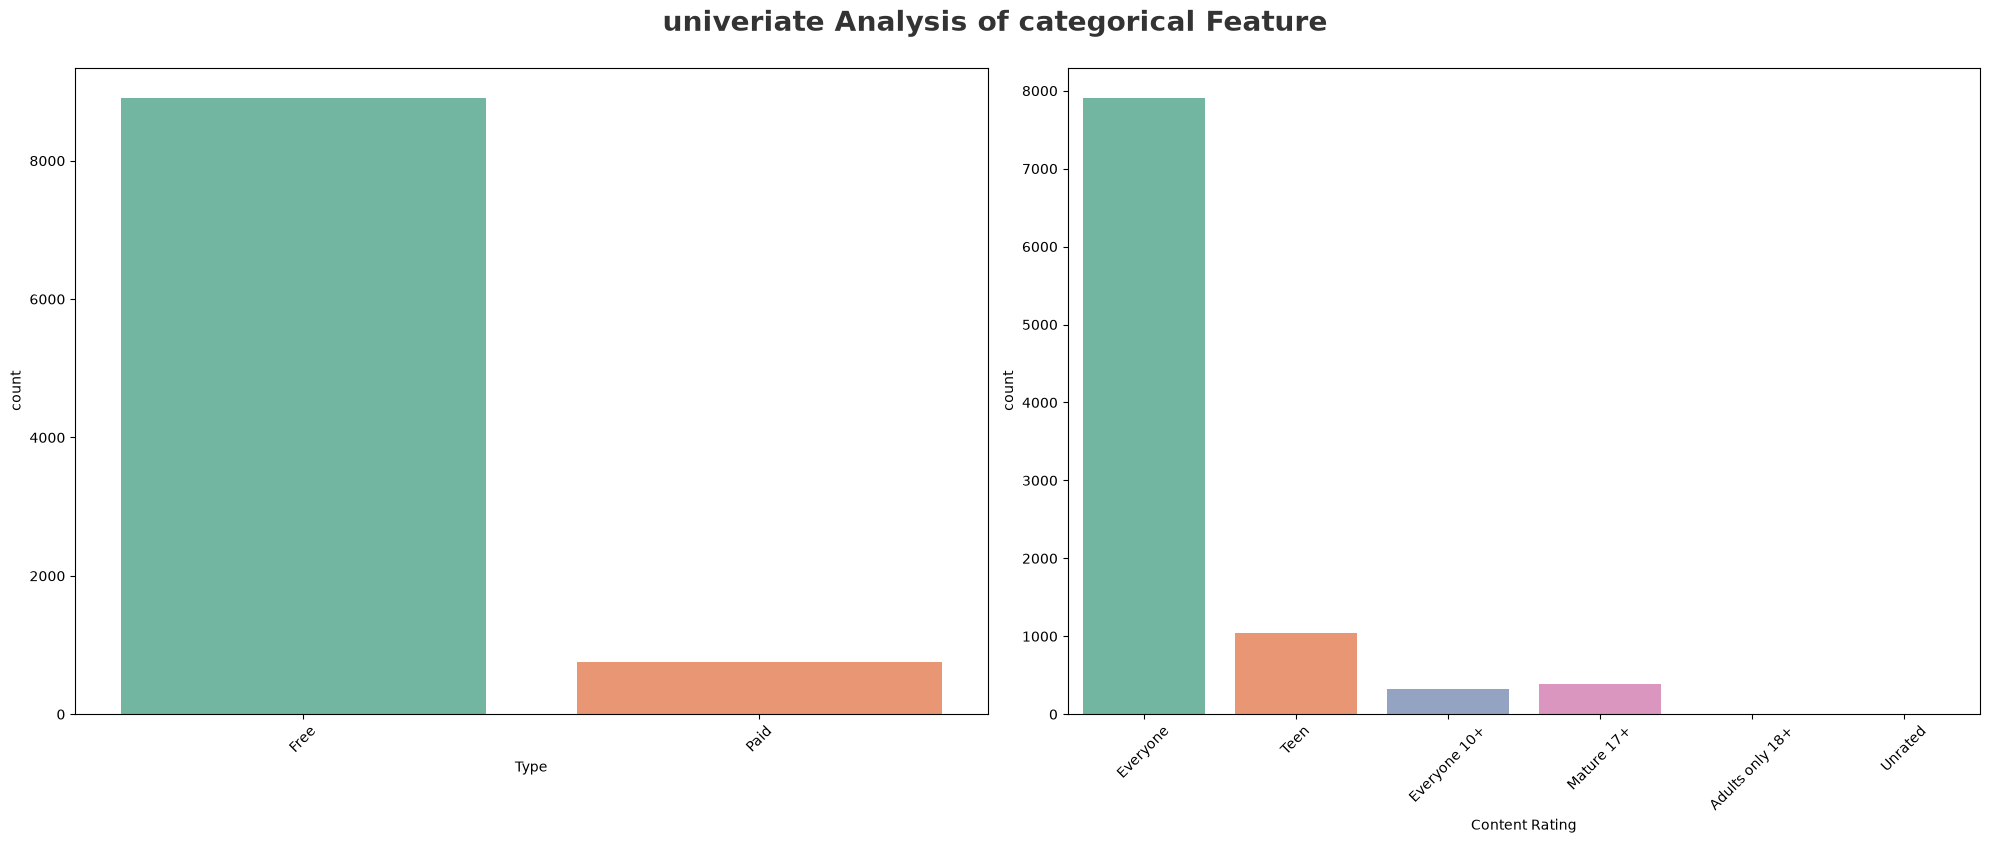

In [57]:
plt.figure(figsize=(20,15))

plt.suptitle("univeriate Analysis of categorical Feature", fontsize=20, fontweight='bold', alpha=0.8, y=1)
category=['Type','Content Rating']

for i in range(0, len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df_copy[category[i]], palette='Set2')
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

<Axes: >

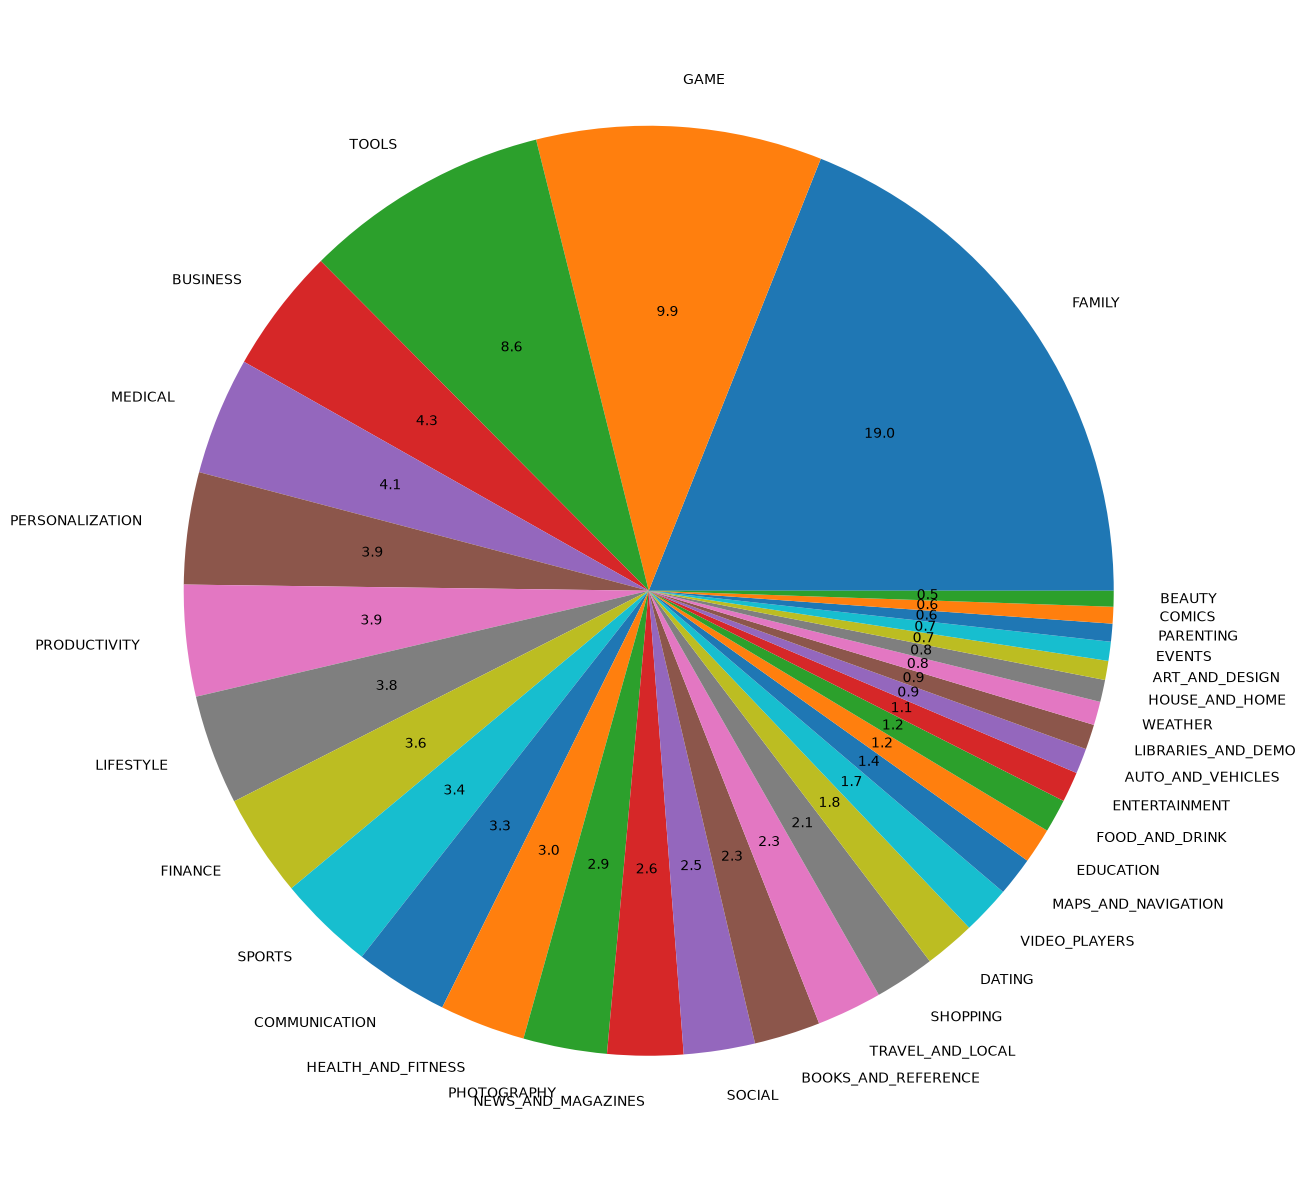

In [58]:
df_copy['Category'].value_counts().plot.pie(y=df['Category'], figsize=(15,16),autopct='%1.1f')

# observations

1. There are more kinds of apps in playstore which are under category of family, games, & tools
2. beauty, comic, and arts are weather kind of apps are very less in playstore

# Top 10 apps categories

In [62]:
category = pd.DataFrame(df['Category'].value_counts())
category.rename(columns = {'Category':'Count'},inplace=True)

In [63]:
category

,count
Category,
FAMILY,1972
GAME,1144
TOOLS,843
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,392
COMMUNICATION,387
SPORTS,384


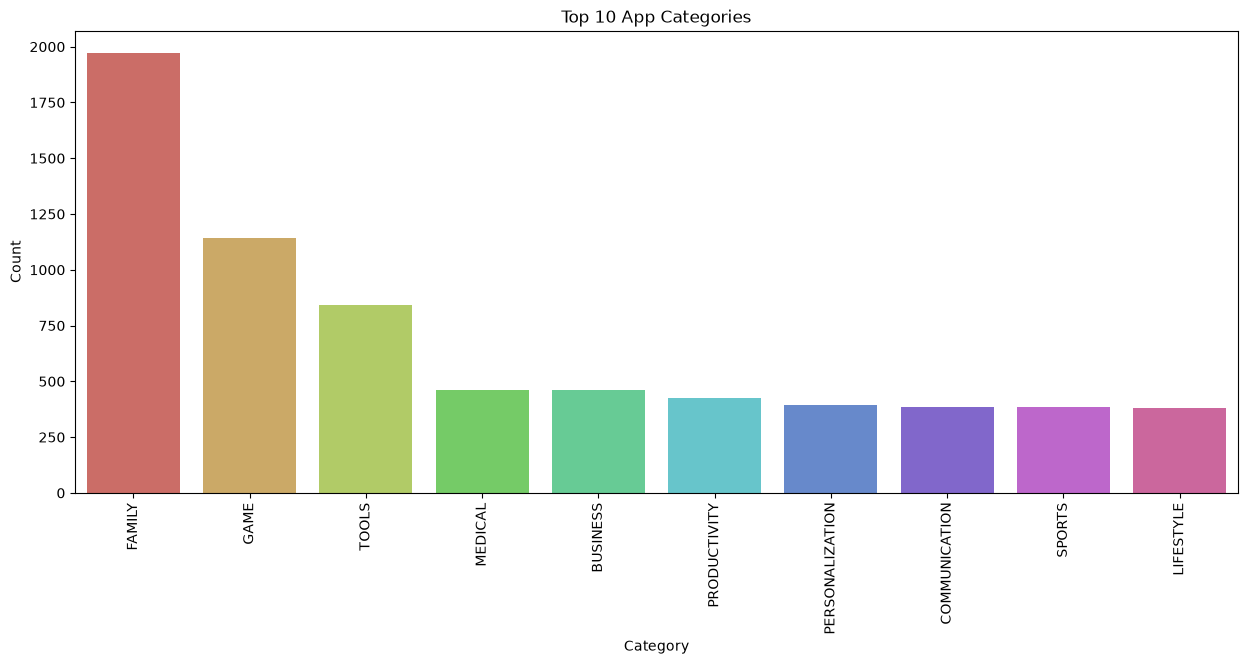

In [ ]:
# Now to see the top 10 categories we create a bar chart
plt.figure(figsize=(15, 6))

# 'count' small letters me
# hue assign kiya taaki naye Seaborn me warning na aaye
sns.barplot(
    x=category.index[:10], 
    y='count', 
    data=category[:10], 
    palette='hls', 
    hue=category.index[:10], 
    legend=False
)

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


## assigment 
- 1. which category has largest number of installations ?
- 2. what are the Top 5 most installed Apps in Each popular Categories ??
- 3. How many apps are there on GPS which get 5 ratings

In [ ]:
df_copy

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,25,7,2017
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up,6,7,2018
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,2017-01-20,1.0,2.2 and up,20,1,2017
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device,19,1,2015
